# Tutorial: Using alternative glacier outlines, DEMs, and WGMS observations for mass-balance calibration

In this tutorial, we rebuild the OGGM glacier directory for `Hintereisferner` using alternative input data. We replace the default glacier outline with a new inventory, use an alternative DEM, and use WGMS observations for mass-balance calibration.

The aim of this tutorial is **not** to provide a universal recipe for mass-balance recalibration. Such a recipe does not really exist: the appropriate calibration strategy depends on the climate product, glacier region, observations available, research question, etc.

Check this publication to understand more about MB calibration challenges:

- Schuster L, Rounce DR, Maussion F. Glacier projections sensitivity to temperature-index model choices and calibration strategies. Annals of Glaciology. 2023;64(92):293-308. doi:10.1017/aog.2023.57. [link](https://www.cambridge.org/core/journals/annals-of-glaciology/article/glacier-projections-sensitivity-to-temperatureindex-model-choices-and-calibration-strategies/EBE19247F4ADC7888EB59EBECB0140B1)

Instead, this tutorial illustrates how to ingest your own data into an OGGM workflow, and which parts of the workflow you need to rethink when changing input data. In particular, we will identify which steps are affected by changing the glacier outline, DEM, and mass-balance observations.

For simplicity, **we keep the same baseline climate product as in the OGGM preprocessing directory**. We also reuse the precipitation factor and temperature bias from that reference setup (`prcp_fac`, `temp_bias`). This is a practical simplification for the tutorial, not a general recommendation. These parameters can also be affected indirectly by changes in glacier geometry, especially if the new outline or DEM significantly changes the glacier hypsometry.

Here, we assume that the alternative outline and DEM describe approximately the same glacier geometry as the reference setup. Under this assumption, we keep the precipitation factor and temperature bias fixed and recalibrate only the melt factor (`melt_f`) using WGMS observations. This allows us to focus on the mechanics of rebuilding the glacier directory and understanding which workflow steps need to be repeated or reconsidered.

## What changes when we use new input data?

- Changing the glacier outline means that we need to redo the GIS tasks, glacier masks, elevation-band flowlines, apparent mass balance, inversion, and present-time glacier initialisation.

- Changing the DEM means that we also need to redo the GIS tasks and flowlines, because the glacier elevation distribution, slopes, and elevation-band areas may change.

- Changing the WGMS observations means that we need to rethink the mass-balance calibration target. 

- Changing the climate product would require a more complete recalibration strategy, including precipitation factor and temperature bias. We do not cover this in this tutorial.

In [1]:
import logging
import sys
import os
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from oggm import cfg, utils, workflow, tasks, DEFAULT_BASE_URL, graphics
from oggm.core import massbalance

In [2]:
log = logging.getLogger(__name__)

## Download the standard oggm directory

In [3]:
cfg.initialize(logging_level="DEBUG")

# Reference gdir only for prcp_fac and temp_bias
cfg.PATHS['working_dir'] = utils.gettempdir(
    dirname='OGGM-reference-prepro',
    reset=True
)

base_url = ('https://cluster.klima.uni-bremen.de/~oggm/'
                'gdirs/oggm_v1.6/L3-L5_files/2025.6/elev_bands/W5E5/per_glacier_spinup')

gdirs = workflow.init_glacier_directories(['RGI60-11.00897'],
                                             from_prepro_level=3,
                                             prepro_base_url=base_url,
                                             prepro_border=80,
                                             prepro_rgi_version='62',
                                             reset=True,
                                             force=True)

gdir_ref = gdirs[0]

mb_calib_ref = gdir_ref.read_json('mb_calib')
fixed_prcp_fac = mb_calib_ref['prcp_fac']
fixed_temp_bias = mb_calib_ref['temp_bias']

2026-06-04 19:27:38: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-06-04 19:27:38: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-06-04 19:27:38: oggm.cfg: Multiprocessing: using all available processors (N=16)
2026-06-04 19:27:38: urllib3.connectionpool: Starting new HTTPS connection (1): cluster.klima.uni-bremen.de:443
2026-06-04 19:27:39: urllib3.connectionpool: https://cluster.klima.uni-bremen.de:443 "GET /~oggm/gdirs/oggm_v1.6/L3-L5_files/2025.6/elev_bands/W5E5/per_glacier_spinup/RGI62/b_080/L3/ HTTP/1.1" 200 3151
2026-06-04 19:27:39: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2026-06-04 19:27:39: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


## Use a different inventory.

In this case we are using a different inventory for simulating the Hintereisferner glacier in the Alps. This new inventory was take from 
[Diaconu, C.‐A., Zekollari, H., & Bamber,J. L. (2025)](https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2025EA004197) and provides outlines for two years 2015 and 2023.

In [4]:
DATA_DIR = Path.cwd().resolve().parents[1] / "Lanzhou_workshop_oggm_tutorials/data"
print(DATA_DIR)

/home/brecinos/Documents/Lanzhou_workshop_oggm_tutorials/data


We are going to read the new inventory

In [5]:
outlines_fp = os.path.join(DATA_DIR, 'outlines_2015/inv_preds_calib.shp')

outline = gpd.read_file(outlines_fp)
outline

,entry_id,image_id,image_date,label,split,tau,geometry
0,g_4363,20150826,2015-08-26,preds_calib,split_1,0.170134,"MULTIPOLYGON (((10.75223 46.78749, 10.75236 46..."


<Axes: >

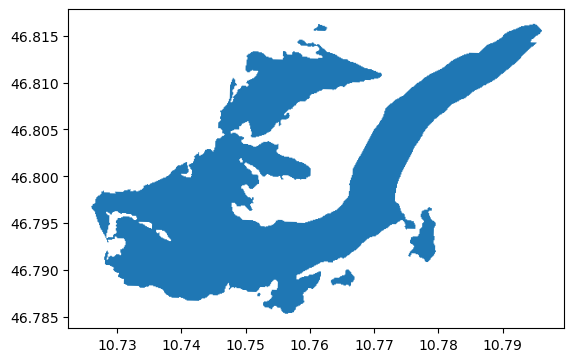

In [6]:
outline.plot()

Lets compare it to the current RGI. Note the change in longitude! Our glacier in 2015 is much smaller than the RGI inventory which is from 2003!

In [7]:
orig = utils.get_rgi_glacier_entities(['RGI60-11.00897'], version='62')
orig

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Lmax,Status,Connect,Form,TermType,Surging,Linkages,Name,check_geom,geometry
896,RGI60-11.00897,G010758E46800N,20030799,20030999,10.7584,46.8003,11,1,8.036,2430,...,7178,0,0,0,0,9,1,Hintereisferner,NaN,"POLYGON ((10.75085 46.81381, 10.75112 46.81397..."


<Axes: >

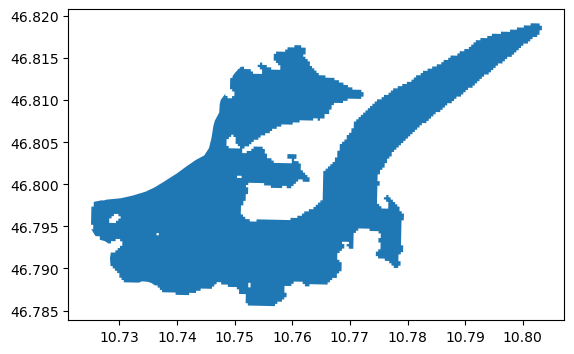

In [8]:
orig.plot()

In [9]:
rgidf_simple = utils.cook_rgidf(outline, o1_region='11')

In [10]:
rgidf_simple

,RGIId,CenLon,CenLat,GLIMSId,BgnDate,EndDate,O1Region,O2Region,Area,Zmin,...,Lmax,Status,Connect,Form,TermType,Surging,Linkages,check_geom,Name,geometry
0,RGI60-11.00001,10.74591,46.800811,,20009999,9999999,11,01,-9999.0,-9999.0,...,-9999,0,0,0,0,0,1,None,,"MULTIPOLYGON (((10.75223 46.78749, 10.75236 46..."


Lets make sure we change the RGIID to the original ID otherwise we wont be able to use standard OGGM util functions like `get_ref_mb_data()` which are very handy to get insitu observations for calibration.

In [11]:
rgidf_simple['RGIId'] = orig['RGIId'].values

In [12]:
rgidf_simple

,RGIId,CenLon,CenLat,GLIMSId,BgnDate,EndDate,O1Region,O2Region,Area,Zmin,...,Lmax,Status,Connect,Form,TermType,Surging,Linkages,check_geom,Name,geometry
0,RGI60-11.00897,10.74591,46.800811,,20009999,9999999,11,01,-9999.0,-9999.0,...,-9999,0,0,0,0,0,1,None,,"MULTIPOLYGON (((10.75223 46.78749, 10.75236 46..."


Before running a workflow with this inventory make sure you have the following configuration:

In [13]:
cfg.PARAMS['use_rgi_area'] = False
cfg.PARAMS['use_intersects'] = False
cfg.PARAMS["border"] = 80

2026-06-04 19:27:39: oggm.cfg: PARAMS['use_rgi_area'] changed from `True` to `False`.
2026-06-04 19:27:39: oggm.cfg: PARAMS['use_intersects'] changed from `True` to `False`.


In [14]:
# OGGM flags that needs to be on for this tutorial and configuration
cfg.PARAMS["continue_on_error"] = True
cfg.PARAMS["use_compression"] = True
cfg.PARAMS["use_tar_shapefiles"] = True
cfg.PATHS["rgi_version"] = "62"
cfg.PARAMS["use_temp_bias_from_file"] = True
cfg.PARAMS["compress_climate_netcdf"] = False
cfg.PARAMS["store_model_geometry"] = True
cfg.PARAMS["store_fl_diagnostics"] = True

2026-06-04 19:27:39: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2026-06-04 19:27:39: oggm.cfg: PARAMS['compress_climate_netcdf'] changed from `True` to `False`.
2026-06-04 19:27:39: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-06-04 19:27:39: oggm.cfg: PARAMS['store_fl_diagnostics'] changed from `False` to `True`.


## Use a different DEM

In this tutorial, we will use a different DEM than the one provided in the preprocessing directory, which uses `COPDEM90` and `COPDEM30`. This is not because the default DEM is unsuitable, but rather to show how you can use an alternative DEM in a simulation and where do you tell oggm about the new DEM.

In [15]:
cfg.PATHS['dem_file'] = utils.get_demo_file('hef_srtm.tif')

## Re-initialise glacier directories 

Above we have retained the calibration information for the mass balance which we will re use later:

```python

mb_calib_ref = gdir_ref.read_json('mb_calib')

fixed_prcp_fac = mb_calib_ref['prcp_fac']
fixed_temp_bias = mb_calib_ref['temp_bias']

print(f'Using fixed prcp_fac = {fixed_prcp_fac}')
print(f'Using fixed temp_bias = {fixed_temp_bias}')
```

In [16]:
# --- Custom directory: rebuilt from new GIS inputs ---
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-custom-geometry',
                                            reset=True)

gdirs = workflow.init_glacier_directories(rgidf_simple, reset=True, force=True)

2026-06-04 19:27:39: oggm.workflow: Execute entity tasks [GlacierDirectory] on 1 glaciers
2026-06-04 19:27:39: pyogrio._io: Created 1 records


## Repeat GIS tasks with new outline and DEM

In [17]:
# this task adds the DEM and defines the local grid
workflow.execute_entity_task(tasks.define_glacier_region, gdirs, source='USER')

2026-06-04 19:27:39: oggm.workflow: Execute entity tasks [define_glacier_region] on 1 glaciers
2026-06-04 19:27:39: oggm.core.gis: (RGI60-11.00897) define_glacier_region
2026-06-04 19:27:40: oggm.core.gis: (RGI60-11.00897) area 6.10 km, dx=45.0
2026-06-04 19:27:40: oggm.core.gis: (RGI60-11.00897) DEM source: USER
2026-06-04 19:27:40: oggm.core.gis: (RGI60-11.00897) N DEM Files: 1


[None]

In [18]:
elevation_band_task_list = [
        tasks.simple_glacier_masks,
        tasks.elevation_band_flowline,
        tasks.fixed_dx_elevation_band_flowline,
        tasks.compute_downstream_line,
        tasks.compute_downstream_bedshape,
    ]

for task in elevation_band_task_list:
    workflow.execute_entity_task(task, gdirs);

2026-06-04 19:27:40: oggm.workflow: Execute entity tasks [simple_glacier_masks] on 1 glaciers
2026-06-04 19:27:40: oggm.core.gis: (RGI60-11.00897) simple_glacier_masks
2026-06-04 19:27:40: oggm.core.gis: (RGI60-11.00897) process_dem
2026-06-04 19:27:40: oggm.workflow: Execute entity tasks [elevation_band_flowline] on 1 glaciers
2026-06-04 19:27:40: oggm.core.centerlines: (RGI60-11.00897) elevation_band_flowline
2026-06-04 19:27:40: oggm.workflow: Execute entity tasks [fixed_dx_elevation_band_flowline] on 1 glaciers
2026-06-04 19:27:40: oggm.core.centerlines: (RGI60-11.00897) fixed_dx_elevation_band_flowline
2026-06-04 19:27:40: oggm.core.centerlines: (RGI60-11.00897) corrected widths with a factor 1.00
2026-06-04 19:27:40: oggm.workflow: Execute entity tasks [compute_downstream_line] on 1 glaciers
2026-06-04 19:27:40: oggm.core.centerlines: (RGI60-11.00897) compute_downstream_line
2026-06-04 19:27:40: oggm.workflow: Execute entity tasks [compute_downstream_bedshape] on 1 glaciers
2026-

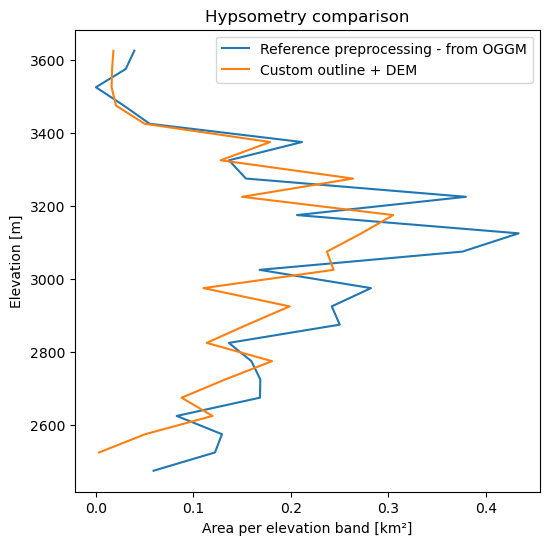

In [19]:
def plot_hypsometry(gdir, label):
    fls = gdir.read_pickle('inversion_flowlines')
    h = np.concatenate([fl.surface_h for fl in fls])
    w = np.concatenate([fl.widths for fl in fls])
    area = w * gdir.grid.dx**2

    bins = np.arange(np.floor(h.min() / 50) * 50,
                     np.ceil(h.max() / 50) * 50 + 50,
                     50)

    hist, edges = np.histogram(h, bins=bins, weights=area)
    z = 0.5 * (edges[:-1] + edges[1:])

    plt.plot(hist * 1e-6, z, label=label)


plt.figure(figsize=(6, 6))

plot_hypsometry(gdir_ref, 'Reference preprocessing - from OGGM')
plot_hypsometry(gdirs[0], 'Custom outline + DEM')

plt.xlabel('Area per elevation band [km²]')
plt.ylabel('Elevation [m]')
plt.legend()
plt.title('Hypsometry comparison')
plt.show()

The custom geometry has a similar elevation range to the reference preprocessing directory, but the area-elevation distribution is not identical, especially between about 2800 and 3200 m. We therefore treat the reuse of `prcp_fac` and `temp_bias` as a practical tutorial simplification. For a research application, this hypsometry difference should be tested as part of the calibration uncertainty via a sensitivity analysis.

## Get climate data

In [20]:
print(cfg.PARAMS['baseline_climate'])
cfg.PARAMS['baseline_climate'] = cfg.PARAMS['baseline_climate']

# add climate data to gdir
workflow.execute_entity_task(tasks.process_climate_data, gdirs)

2026-06-04 19:27:40: oggm.workflow: Execute entity tasks [process_climate_data] on 1 glaciers
2026-06-04 19:27:40: oggm.core.climate: (RGI60-11.00897) process_climate_data
2026-06-04 19:27:40: oggm.shop.w5e5: (RGI60-11.00897) process_gswp3_w5e5_data


GSWP3_W5E5


[None]

## Get insitu reference mass balance

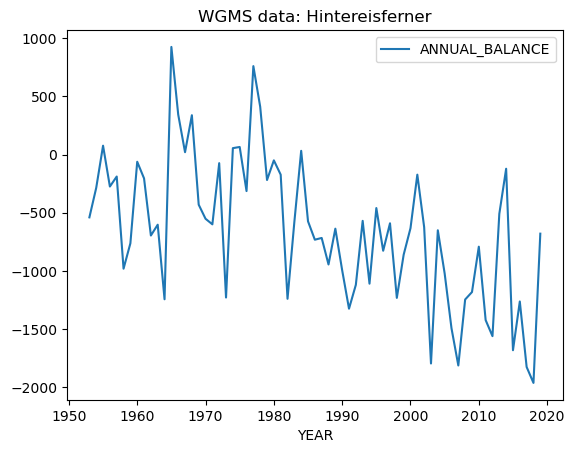

In [21]:
for gdir in gdirs: 
    mb = gdir.get_ref_mb_data()

mb[['ANNUAL_BALANCE']].plot(title='WGMS data: Hintereisferner');

In [22]:
mb

,WGMS_ID,POLITICAL_UNIT,NAME,AREA,WINTER_BALANCE,SUMMER_BALANCE,ANNUAL_BALANCE,REMARKS,RGI_ID
YEAR,,,,,,,,,
1953,491,AT,HINTEREIS F.,NaN,NaN,NaN,-540.0,NaN,RGI60-11.00897
1954,491,AT,HINTEREIS F.,NaN,NaN,NaN,-286.0,NaN,RGI60-11.00897
1955,491,AT,HINTEREIS F.,NaN,NaN,NaN,76.0,NaN,RGI60-11.00897
1956,491,AT,HINTEREIS F.,NaN,NaN,NaN,-275.0,NaN,RGI60-11.00897
1957,491,AT,HINTEREIS F.,NaN,NaN,NaN,-189.0,NaN,RGI60-11.00897
...,...,...,...,...,...,...,...,...,...
2015,491,AT,HINTEREIS F.,6.659,1367.0,-3049.0,-1682.0,NaN,RGI60-11.00897
2016,491,AT,HINTEREIS F.,6.659,948.0,-2210.0,-1263.0,NaN,RGI60-11.00897
2017,491,AT,HINTEREIS F.,6.659,892.0,-2718.0,-1826.0,NaN,RGI60-11.00897


## Scalar MB recalibration with insitu data

In [23]:
print('prcp_fac:', mb_calib_ref['prcp_fac'], type(mb_calib_ref['prcp_fac']))
print('temp_bias:', mb_calib_ref['temp_bias'], type(mb_calib_ref['temp_bias']))
print('melt_f:', mb_calib_ref['melt_f'], type(mb_calib_ref['melt_f']))

prcp_fac: 3.570255710475343 <class 'float'>
temp_bias: 1.705035916562294 <class 'float'>
melt_f: 5.0 <class 'float'>


In [24]:
results = []

for gdir in gdirs:

    gdir.observations['ref_mb'] = {
        'value': mb['ANNUAL_BALANCE'].mean(),
        'unit': 'kg m-2 yr-1',
        'years': mb.index.values
    }

    mb_calib_scalar = massbalance.mb_calibration_from_scalar_mb(gdir,
                                              prcp_fac=mb_calib_ref['prcp_fac'],
                                              temp_bias=mb_calib_ref['temp_bias'],
                                              calibrate_param1='melt_f',
                                              calibrate_param2=None,
                                              calibrate_param3=None,
                                              overwrite_gdir=True
                                             )

    # Save a copy with a suffix so it is not lost later
    gdir.write_json(mb_calib_scalar, 'mb_calib', filesuffix='_scalar_wgms')

    results.append({
        'case': 'Custom geometry - scalar WGMS calibration',
        'rgi_id': gdir.rgi_id,
        'melt_f': mb_calib_scalar['melt_f'],
        'prcp_fac': mb_calib_scalar['prcp_fac'],
        'temp_bias': mb_calib_scalar['temp_bias'],
    })

2026-06-04 19:27:40: oggm.core.massbalance: (RGI60-11.00897) mb_calibration_from_scalar_mb


In [25]:
results.append({
        'case': 'Reference preprocessing',
        'rgi_id': gdir.rgi_id,
        'melt_f': mb_calib_ref['melt_f'],
        'prcp_fac': mb_calib_ref['prcp_fac'],
        'temp_bias': mb_calib_ref['temp_bias'],
    })

In [26]:
import pandas as pd

df_calib = pd.DataFrame(results)

ref_melt_f = mb_calib_ref['melt_f']
df_calib['melt_f_change_from_ref_%'] = (
    (df_calib['melt_f'] - ref_melt_f) / ref_melt_f * 100
)

df_calib

,case,rgi_id,melt_f,prcp_fac,temp_bias,melt_f_change_from_ref_%
0,Custom geometry - scalar WGMS calibration,RGI60-11.00897,6.076831,3.570256,1.705036,21.536616
1,Reference preprocessing,RGI60-11.00897,5.000000,3.570256,1.705036,0.000000


The +21.5% change in `melt_f` cannot be attributed only to the custom outline or DEM. It reflects the combined effect of:

1. using a different outline and DEM;
2. changing the glacier hypsometry and elevation-band geometry;
3. changing the calibration target from Hugonnet geodetic mass balance to WGMS annual mass-balance observations;
4. keeping `prcp_fac` and `temp_bias` fixed from the reference preprocessing setup.

This comparison illustrates an important point: when you use your own input data in OGGM, calibration is not just a technical step to repeat at the end. It is part of the experiment design. OGGM’s standard calibration workflow was developed for a specific combination of glacier outlines, DEMs, climate products, and reference observations. If you change one of these inputs, you need to think carefully about which workflow steps must be repeated, which parameters can reasonably be reused, and how the recalibrated parameters should be interpreted.

In [27]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'climate_historical.nc',
 'glacier_grid.json',
 'inversion_flowlines.pkl',
 'log.txt',
 'observations.yml',
 'settings.yml',
 'outlines.tar.gz',
 'gridded_data.nc',
 'mb_calib_scalar_wgms.json',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

### Lets re-write the `mb_calib` file.

In [28]:
for gdir in gdirs:
    mb_calib_scalar = gdir.read_json('mb_calib', filesuffix='_scalar_wgms')
    gdir.write_json(mb_calib_scalar, 'mb_calib')  # writes mb_calib.json

In [29]:
os.listdir(gdirs[0].dir)

['elevation_band_flowline.csv',
 'climate_historical.nc',
 'glacier_grid.json',
 'inversion_flowlines.pkl',
 'log.txt',
 'observations.yml',
 'settings.yml',
 'outlines.tar.gz',
 'gridded_data.nc',
 'mb_calib_scalar_wgms.json',
 'mb_calib.json',
 'dem.tif',
 'diagnostics.json',
 'dem_source.txt',
 'downstream_line.pkl']

In [30]:
workflow.execute_entity_task(tasks.apparent_mb_from_any_mb, gdirs)

2026-06-04 19:27:41: oggm.workflow: Execute entity tasks [apparent_mb_from_any_mb] on 1 glaciers
2026-06-04 19:27:41: oggm.core.massbalance: (RGI60-11.00897) apparent_mb_from_any_mb


[None]

## Calibrating ice dynamics and creating dynamic flowlines

In [31]:
# Calibrate inversion parameters / volume using the consensus estimate
workflow.calibrate_inversion_from_consensus(
    gdirs,
    apply_fs_on_mismatch=True,
    error_on_mismatch=True,
    filter_inversion_output=True,
)

# Finally create the dynamic flowlines
workflow.execute_entity_task(tasks.init_present_time_glacier, gdirs)

2026-06-04 19:27:41: oggm.workflow: Applying global task calibrate_inversion_from_consensus on 1 glaciers
2026-06-04 19:27:41: oggm.workflow: Applying global task calibrate_inversion_from_volume on 1 glaciers
2026-06-04 19:27:41: oggm.workflow: Volume estimate optimisation with A factor: 0.1 and fs: 0
2026-06-04 19:27:41: oggm.workflow: Applying global task inversion_tasks on 1 glaciers
2026-06-04 19:27:41: oggm.workflow: Execute entity tasks [prepare_for_inversion] on 1 glaciers
2026-06-04 19:27:41: oggm.core.inversion: (RGI60-11.00897) prepare_for_inversion
2026-06-04 19:27:41: oggm.workflow: Execute entity tasks [mass_conservation_inversion] on 1 glaciers
2026-06-04 19:27:41: oggm.core.inversion: (RGI60-11.00897) mass_conservation_inversion
2026-06-04 19:27:41: oggm.workflow: Execute entity tasks [filter_inversion_output] on 1 glaciers
2026-06-04 19:27:41: oggm.core.inversion: (RGI60-11.00897) filter_inversion_output
2026-06-04 19:27:41: oggm.workflow: Execute entity tasks [get_inve

[None]

## Run historical simulation with and without spin-up

Note that there is no need to run the `run_dynamic_melt_f_calibration` because in our example we have already calibrated with WGMS data. If you are using already in-situ observations there is no need to re-calibrate `melt_f` you just need to run a standard spin-up. 

In [32]:
cfg.PARAMS['evolution_model'] = 'SemiImplicit'

y0 = gdirs[0].get_climate_info()['baseline_yr_0']
ye = gdirs[0].get_climate_info()['baseline_yr_1'] + 1

workflow.execute_entity_task(
    tasks.run_from_climate_data,
    gdirs,
    ys=y0,
    ye=ye,
    output_filesuffix='_custom_wgms_historical',
    store_fl_diagnostics=True,
)

2026-06-04 19:28:16: oggm.workflow: Execute entity tasks [run_from_climate_data] on 1 glaciers
2026-06-04 19:28:16: oggm.core.flowline: (RGI60-11.00897) run_from_climate_data_custom_wgms_historical
2026-06-04 19:28:16: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-06-04 19:28:16: oggm.core.flowline: (RGI60-11.00897) flowline_model_run_custom_wgms_historical


In [33]:
workflow.execute_entity_task(
    tasks.run_dynamic_spinup,
    gdirs,
    spinup_start_yr=1979,
    ye=ye,
    minimise_for='area',
    output_filesuffix='_wgms_calib_dynamic_spinup',
    store_fl_diagnostics=True,
    ignore_errors=True,
)

2026-06-04 19:28:39: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-06-04 19:28:39: oggm.core.dynamic_spinup: (RGI60-11.00897) run_dynamic_spinup_wgms_calib_dynamic_spinup


In [34]:
os.listdir(gdirs[0].dir)

['fl_diagnostics_wgms_calib_dynamic_spinup.nc',
 'model_geometry_wgms_calib_dynamic_spinup.nc',
 'elevation_band_flowline.csv',
 'inversion_input.pkl',
 'climate_historical.nc',
 'glacier_grid.json',
 'model_flowlines.pkl',
 'model_diagnostics_wgms_calib_dynamic_spinup.nc',
 'inversion_flowlines.pkl',
 'log.txt',
 'observations.yml',
 'settings.yml',
 'model_diagnostics_custom_wgms_historical.nc',
 'model_geometry_custom_wgms_historical.nc',
 'outlines.tar.gz',
 'gridded_data.nc',
 'mb_calib_scalar_wgms.json',
 'mb_calib.json',
 'dem.tif',
 'inversion_output.pkl',
 'diagnostics.json',
 'dem_source.txt',
 'fl_diagnostics_custom_wgms_historical.nc',
 'downstream_line.pkl']

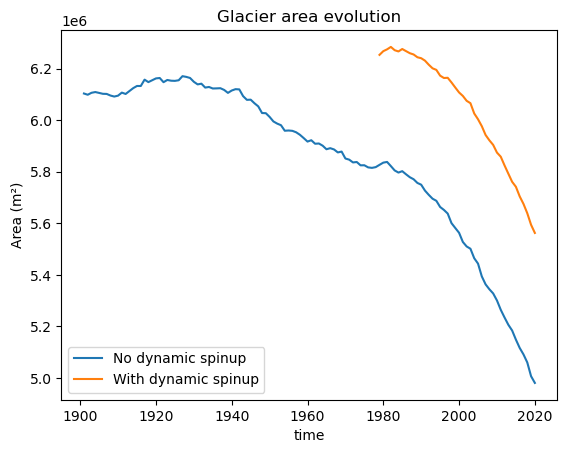

In [35]:
import xarray as xr
import matplotlib.pyplot as plt

gdir = gdirs[0]

f = gdir.get_filepath('model_diagnostics', filesuffix='_custom_wgms_historical')
with xr.open_dataset(f) as ds:
    ds_no_spinup = ds.load()

f = gdir.get_filepath('model_diagnostics', filesuffix='_wgms_calib_dynamic_spinup')
with xr.open_dataset(f) as ds:
    ds_spinup = ds.load()

ds_no_spinup.area_m2.plot(label='No dynamic spinup')
ds_spinup.area_m2.plot(label='With dynamic spinup')

plt.title('Glacier area evolution')
plt.ylabel('Area (m²)')
plt.legend()

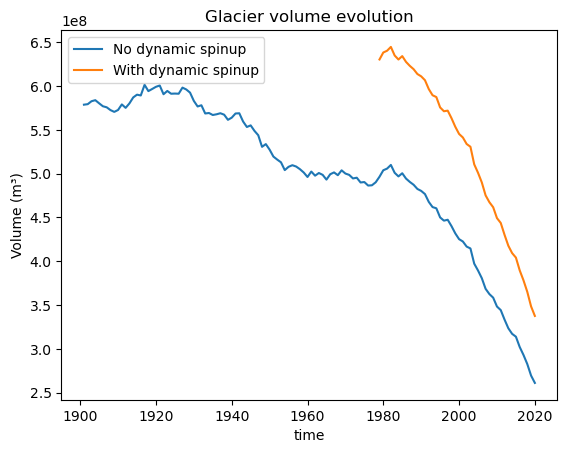

In [36]:
ds_no_spinup.volume_m3.plot(label='No dynamic spinup')
ds_spinup.volume_m3.plot(label='With dynamic spinup')

plt.title('Glacier volume evolution')
plt.ylabel('Volume (m³)')
plt.legend()

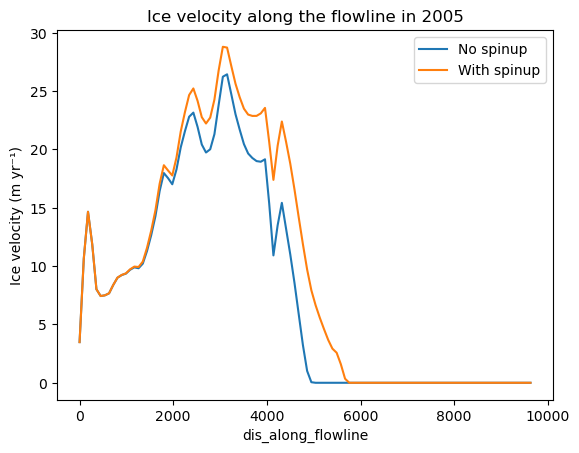

In [40]:
f = gdir.get_filepath('fl_diagnostics', filesuffix='_custom_wgms_historical')
with xr.open_dataset(f, group='fl_0') as ds:
    dg_no = ds.load()

f = gdir.get_filepath('fl_diagnostics', filesuffix='_wgms_calib_dynamic_spinup')
with xr.open_dataset(f, group='fl_0') as ds:
    dg_spin = ds.load()

year = 2005

dg_no.ice_velocity_myr.sel(time=year).plot(label='No spinup')
dg_spin.ice_velocity_myr.sel(time=year).plot(label='With spinup')

plt.title(f'Ice velocity along the flowline in {year}')
plt.ylabel('Ice velocity (m yr⁻¹)')
plt.legend()

The size of the difference between the “no spinup” and “with spinup” velocity profiles tells us how much the dynamic spinup had to modify the glacier state.

In the custom WGMS-calibrated experiment, the no-spinup and spinup profiles are relatively similar. This suggests that the manually calibrated mass-balance parameters and the custom 2015 geometry already produce an initial glacier state that is reasonably consistent with the spinup target.

[In the standard-style dynamic melt-factor calibration experiment](https://tutorials.oggm.org/stable/notebooks/tutorials/dynamical_spinup.html#high-level-explanation-of-run-dynamic-melt-f-calibration), the profiles differ much more. This is expected because the dynamic spinup is not only finding a dynamically consistent glacier state, but also recalibrating the melt factor during the spinup procedure (we dont do that here!). This can substantially modify the ice thickness distribution, and because ice velocity is highly sensitive to ice thickness and slope, the resulting velocity profile can change strongly.